## Import libraries

In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.signal import savgol_filter

from unityvr.preproc import logproc
from unityvr.viz import viz

import pycircstat

## Data file

In [2]:
dirName = '/Volumes/otopaliklab/Aisha/Data/Test behavior/Fly04/'
fileName = "Log_2025-09-08_17-45-54_Fly04G.json"

dat = logproc.openUnityLog(dirName, fileName)

for i in range(5):
    print(dat[i]['frame'])
    print(json.dumps(dat[i], sort_keys=True, indent=4))

0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "headerNotes": "darkspot-20degspot-fh- 125degpersec-120fps- anglerange90deg-- panWidth_px-1504-panHeight_px-606 RED OFF                                           ",
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
0.0
{
    "frame": 0.0,
    "frameAfterSplash": 0.0,
    "heightPixels": 720,
    "refreshRateHz": 120,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0,
    "widthPixels": 480
}
1.0
{
    "ficTracBallRadius": 0.04500000178813934,
    "ficTracServerAddress": "127.0.0.1",
    "ficTracServerPort": 2000,
    "ficTracSmoothingCount": 1,
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0
}
1.0
{
    "colliderType": "MeshCollider",
    "frame": 1.0,
    "frameAfterSplash": 1.0,
    "meshGameObjectPath": "Fly/FlyCamera4/FlyCamera4Screen",
    "timeSecs": 0.0,
    "timeSecsAfterSplash": 0.0,
    "worldPosition": {
        "x": -1.2334438562393188,
        "y": 0.0099999997

### Construct data object from log file
#### Extract header info

In [3]:
#print(dat[0]['headerNotes'])
logproc.makeMetaDict(dat, fileName)

{'expid': 'testExp',
 'experiment': 'test experiment',
 'genotype': 'testGenotype',
 'sex': 'NA',
 'flyid': 'NA',
 'trial': 'trially04G',
 'date': '2025-09-08',
 'time': '17-45-54',
 'ballRad': 0.04500000178813934,
 'translationalGain': 1.0,
 'setFrameRate': 120,
 'notes': 'NA',
 'temperature': 'NA',
 'angle_convention': 'right-handed'}

#### Pull out object positions as pandas dataframe

In [4]:
objDf = logproc.objDfFromLog(dat)
objDf.head()

,name,collider,px,py,pz,rx,ry,rz,sx,sy,sz
0,Fly/FlyCamera4/FlyCamera4Screen,MeshCollider,-1.233444,-3.796151,0.01,0.0,0.0,18.000004,5.800001,1.0,9.5
1,Fly/FlyCamera1/FlyCamera1Screen,MeshCollider,-1.233444,3.79615,0.01,0.0,0.0,162.0,5.8,1.0,9.5
2,Fly/FlyCamera2/FlyCamera2Screen,MeshCollider,3.229198,2.34615,0.01,0.0,0.0,234.0,5.800001,1.0,9.5
3,Fly/FlyCamera3/FlyCamera3Screen,MeshCollider,3.229198,-2.346149,0.01,0.0,0.0,306.0,5.8,1.0,9.5
4,BackgroundCylinder/default,NA,0.0,0.0,0.01,0.0,0.0,90.0,-3.992001,3.992001,4.75


#### Pull out fly position as pandas dataframe
Position in VR

In [5]:
posDf, ftDf, tsDf = logproc.timeseriesDfFromLog(dat)

correcting for Unity angle convention.


In [6]:
print(len(posDf))
posDf.head()

14777


,frame,time,dt,x,y,angle,dx_ft,dy_ft,dxattempt_ft,dyattempt_ft
0,1.0,0.000000,0.020000,0.000000,-10.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2.0,0.020000,0.020000,0.000000,-10.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3.0,0.028325,0.008325,-0.000036,-9.999782,359.892309,-0.000036,0.000218,-0.000036,0.000218
3,4.0,0.039068,0.010743,-0.000036,-9.999782,359.892309,0.000000,0.000000,0.000000,0.000000
4,5.0,0.053422,0.014354,-0.000036,-9.999782,359.892309,0.000000,0.000000,0.000000,0.000000


In [7]:
# Extract ball radius
matching = [s for s in dat if "ficTracBallRadius" in s]
ballRadius = matching[0]["ficTracBallRadius"]
print(ballRadius) # in decimeters

#conversion factor to cm
dc2cm = 10

0.04500000178813934


### Plot trajectory

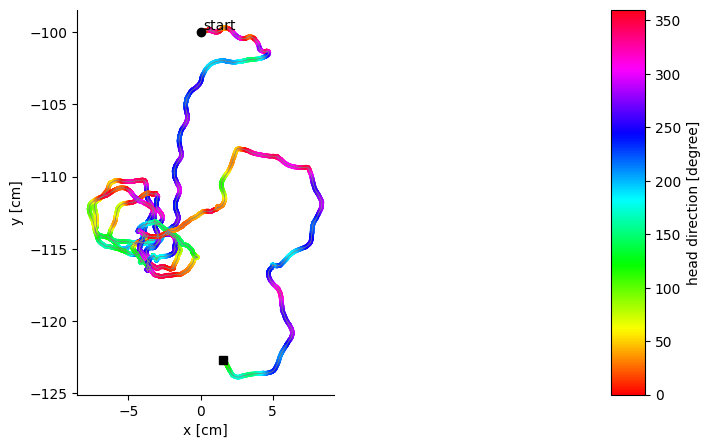

In [8]:
# plot trajectory

from unityvr.viz.utils import myAxisTheme

fig, axs = plt.subplots(1,2,figsize=(10,5), gridspec_kw={'width_ratios':[20,1]})
axs[0].plot(posDf.x*dc2cm,posDf.y*dc2cm,color='grey', linewidth=0.5)
cb = axs[0].scatter(posDf.x*dc2cm,posDf.y*dc2cm,s=5,c=posDf.angle, cmap='hsv')
axs[0].plot(posDf.x[0]*dc2cm,posDf.y[0]*dc2cm,'ok')
axs[0].text(posDf.x[0]*dc2cm+0.2,posDf.y[0]*dc2cm+0.2,'start')
axs[0].plot(posDf.x.values[-1]*dc2cm,posDf.y.values[-2]*dc2cm,'sk')
axs[0].set_aspect('equal')
axs[0].set_xlabel('x [cm]')
axs[0].set_ylabel('y [cm]')
myAxisTheme(axs[0])
plt.colorbar(cb,cax=axs[1], label='head direction [degree]')

### Plot head direction/angle from posDf

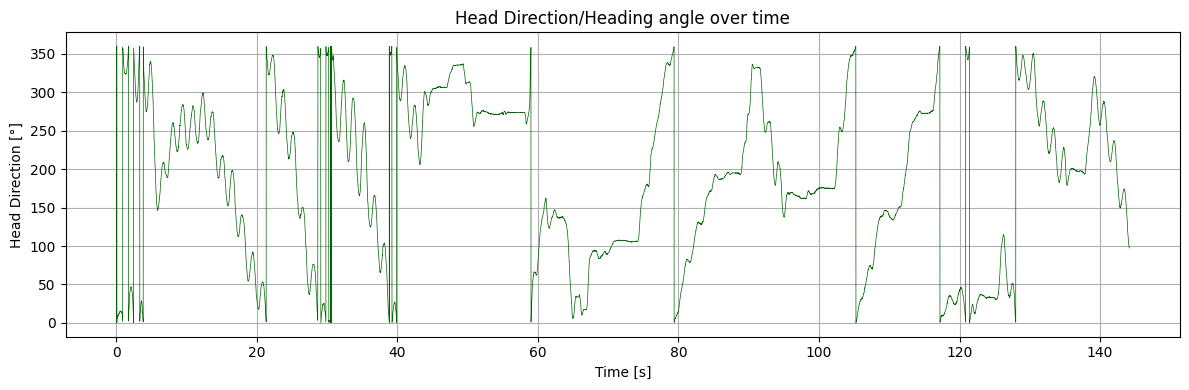

In [9]:
# Head direction (angle from posDf) over time
plt.figure(figsize=(12, 4))
plt.plot(posDf.time, posDf.angle, color='darkgreen', linewidth=0.5)
plt.xlabel('Time [s]')
plt.ylabel('Head Direction [°]')
plt.title('Head Direction/Heading angle over time')
plt.grid(True)
plt.tight_layout()
plt.show()

### Center head direction around 0 degrees

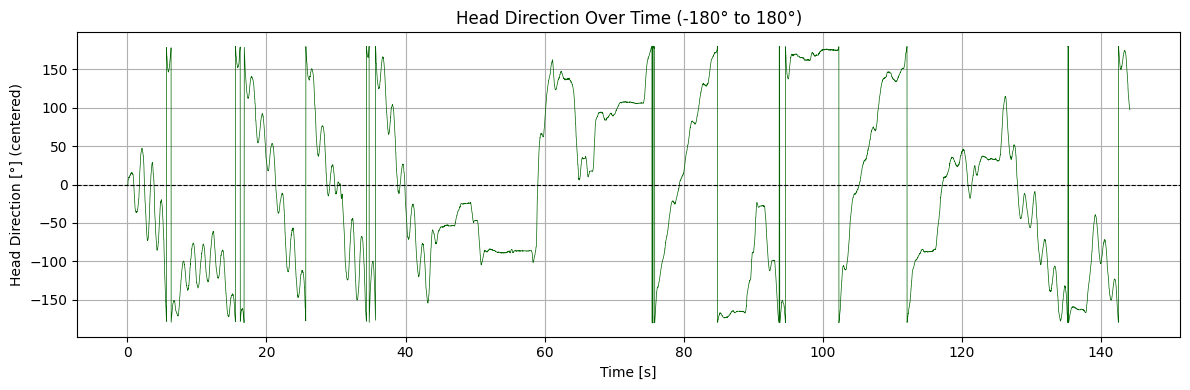

In [10]:
# Convert angle to range [-180, 180)
def normalize_angle(angle_deg):
    return ((angle_deg + 180) % 360) - 180

# Apply transformation
normalized_angle = normalize_angle(posDf.angle)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(posDf.time, normalized_angle, color='darkgreen', linewidth=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Time [s]')
plt.ylabel('Head Direction [°] (centered)')
plt.title('Head Direction Over Time (-180° to 180°)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Import the stimulus angular position and plot it

In [16]:
from decimal import Decimal

df = pd.read_csv(
    '/Users/hamida/Documents/GitHub/UnityStimulusProtocols/movies/new/darkspot-20degspot-fh-125degpersec-120fps-anglerange90deg--panWidth_px-1504-panHeight_px-606/imageDf.csv',
    converters={
        'time [s]': Decimal,
        'angular_shift (deg)': Decimal
    }
)

print(df.head())

   frame              time [s] filename  shifts (px)  angular_shift (deg)
0      1                   0.0    1.png         -188                -45.0
1      2  0.008372093023255813    2.png         -184   -43.95348837209302
2      3  0.016744186046511626    3.png         -179  -42.906976744186046
3      4   0.02511627906976744    4.png         -175  -41.860465116279066
4      5   0.03348837209302325    5.png         -171   -40.81395348837209


### Plot one oscillation

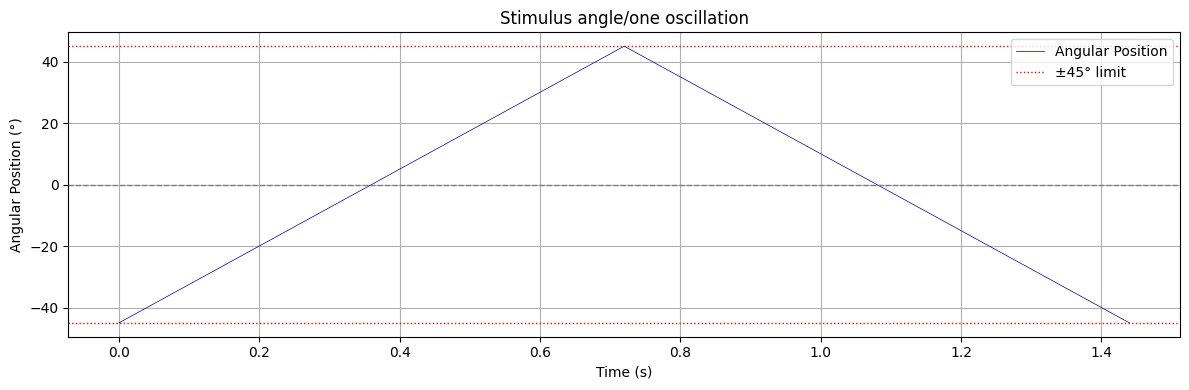

In [17]:
# Plot angle vs time
plt.figure(figsize=(12, 4))
plt.plot(df['time [s]'], df['angular_shift (deg)'], color='darkblue', label='Angular Position', linewidth=0.5)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(45, color='red', linestyle=':', linewidth=1, label='±45° limit')
plt.axhline(-45, color='red', linestyle=':', linewidth=1)
plt.title('Stimulus angle/one oscillation')
plt.xlabel('Time (s)')
plt.ylabel('Angular Position (°)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Plot stimulus over time with heading angle (centred around 0 degree)

In [21]:
from decimal import Decimal, ROUND_CEILING

# convert posDf time column to Decimal
posDf['time'] = posDf['time'].apply(lambda x: Decimal(str(x)))

stimulus_duration = df['time [s]'].max()     # Decimal
total_duration = posDf['time'].max()         # now also Decimal

num_repeats = (total_duration / stimulus_duration).to_integral_value(rounding=ROUND_CEILING)
print(num_repeats, type(num_repeats))


101 <class 'decimal.Decimal'>


In [23]:
repeated_stimulus_dfs = []
offset = Decimal(0)

while offset <= total_duration:
    temp = df.copy()
    temp['time [s]'] = temp['time [s]'].apply(lambda x: x + offset)
    repeated_stimulus_dfs.append(temp)
    offset += stimulus_duration  # still a Decimal

repeated_df = pd.concat(repeated_stimulus_dfs, ignore_index=True)
repeated_df = repeated_df[repeated_df['time [s]'] <= total_duration]


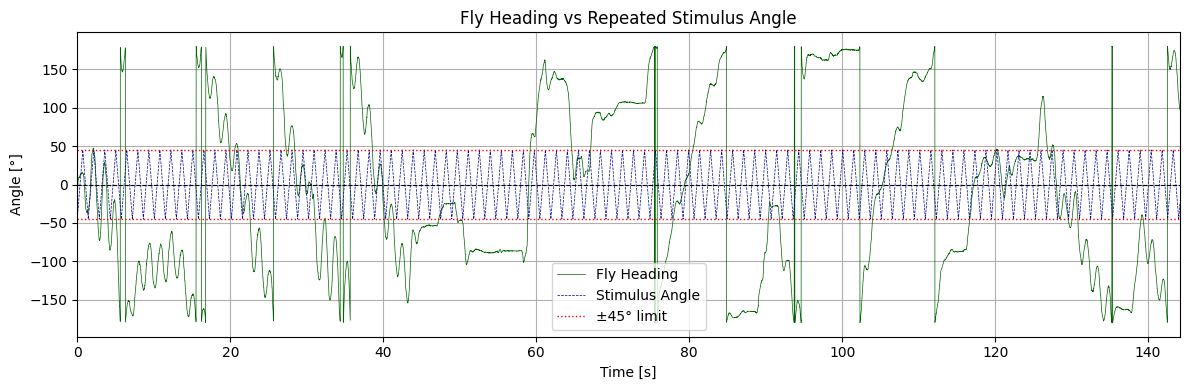

In [24]:
plt.figure(figsize=(12, 4))

# Fly heading (x and y as floats)
plt.plot(
    posDf['time'].astype(float),
    normalized_angle.astype(float),
    color='darkgreen', linewidth=0.5, label='Fly Heading'
)

# Repeated stimulus
plt.plot(
    repeated_df['time [s]'].astype(float),
    repeated_df['angular_shift (deg)'].astype(float),
    color='darkblue', linestyle='--', linewidth=0.5, label='Stimulus Angle'
)

# Reference lines
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axhline(45, color='red', linestyle=':', linewidth=1, label='±45° limit')
plt.axhline(-45, color='red', linestyle=':', linewidth=1)

# Match time axis (also cast to float)
plt.xlim(0, float(total_duration))

plt.xlabel('Time [s]')
plt.ylabel('Angle [°]')
plt.title('Fly Heading vs Repeated Stimulus Angle')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [48]:
# Convert to radians
angle_rad = np.deg2rad(normalized_angle)

# Unwrap to remove discontinuities from -π to +π
unwrapped_angle = np.unwrap(angle_rad)


In [49]:
# Convert time to float (seconds)
time_sec = posDf['time'].astype(float).values

# Compute angular velocity (rad/s)
angular_velocity = np.gradient(unwrapped_angle, time_sec)


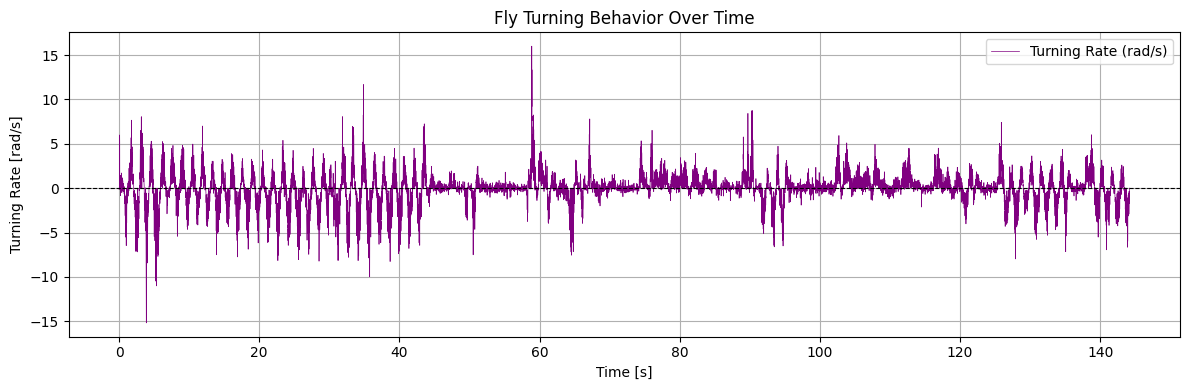

In [50]:
plt.figure(figsize=(12, 4))
plt.plot(time_sec, angular_velocity, color='purple', linewidth=0.5, label='Turning Rate (rad/s)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Time [s]')
plt.ylabel('Turning Rate [rad/s]')
plt.title('Fly Turning Behavior Over Time')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

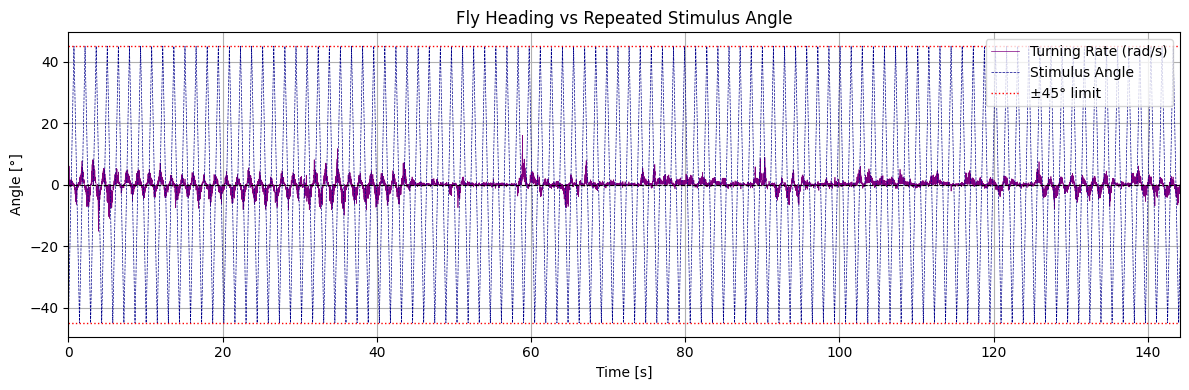

In [51]:
plt.figure(figsize=(12, 4))

# Fly heading (x and y as floats)
plt.plot(time_sec, angular_velocity, color='purple', linewidth=0.5, label='Turning Rate (rad/s)')

# Repeated stimulus
plt.plot(
    repeated_df['time [s]'].astype(float),
    repeated_df['angular_shift (deg)'].astype(float),
    color='darkblue', linestyle='--', linewidth=0.5, label='Stimulus Angle'
)

# Reference lines
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axhline(45, color='red', linestyle=':', linewidth=1, label='±45° limit')
plt.axhline(-45, color='red', linestyle=':', linewidth=1)

# Match time axis (also cast to float)
plt.xlim(0, float(total_duration))

plt.xlabel('Time [s]')
plt.ylabel('Angle [°]')
plt.title('Fly Heading vs Repeated Stimulus Angle')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

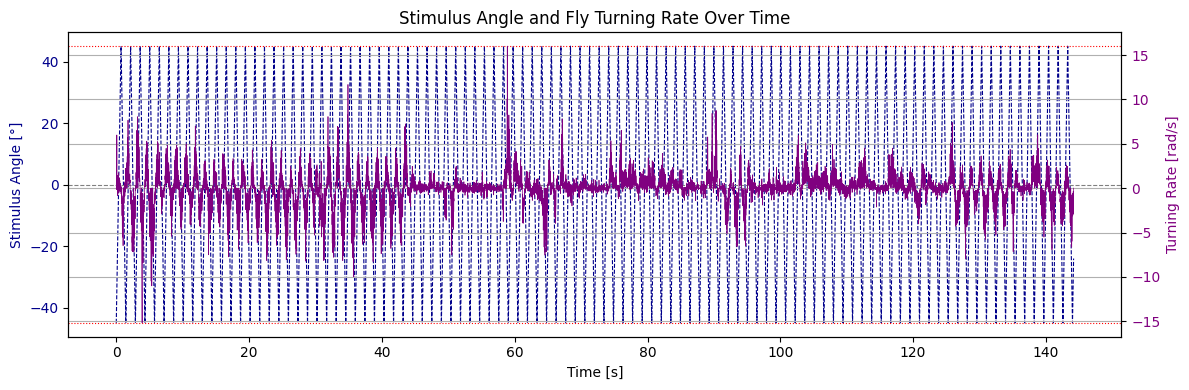

In [52]:
fig, ax1 = plt.subplots(figsize=(12, 4))

# --- Left Y-axis: Stimulus Angle ---
ax1.plot(
    repeated_df['time [s]'].astype(float),
    repeated_df['angular_shift (deg)'].astype(float),
    color='darkblue', linestyle='--', linewidth=0.8,
    label='Stimulus Angle (°)'
)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Stimulus Angle [°]', color='darkblue')
ax1.tick_params(axis='y', labelcolor='darkblue')
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.axhline(45, color='red', linestyle=':', linewidth=0.8)
ax1.axhline(-45, color='red', linestyle=':', linewidth=0.8)

# --- Right Y-axis: Fly Turning Rate ---
ax2 = ax1.twinx()
ax2.plot(
    time_sec,
    angular_velocity,
    color='purple', linewidth=0.5,
    label='Turning Rate (rad/s)'
)
ax2.set_ylabel('Turning Rate [rad/s]', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

# --- Finalize Plot ---
plt.title('Stimulus Angle and Fly Turning Rate Over Time')
fig.tight_layout()
plt.grid(True)
plt.show()


### Cross correlation between the stimulus angle and fly heading

In [25]:
# Extract time & signals (float ONLY for compute/plot)
t = posDf['time'].astype(float).to_numpy()  # seconds
fly = np.asarray(normalized_angle, dtype=float)

ts = repeated_df['time [s]'].astype(float).to_numpy()
stim = repeated_df['angular_shift (deg)'].astype(float).to_numpy()


In [26]:

#Interpolate stimulus to fly time base
stim_i = np.interp(t, ts, stim)

# (Optional) restrict to overlapping range only (np.interp already handles edges)
# mask = (t >= ts.min()) & (t <= ts.max())
# t, fly, stim_i = t[mask], fly[mask], stim_i[mask]


In [27]:

# Z-score (mean-center, unit variance) for normalized cross-correlation
fly_z  = fly - np.nanmean(fly)
stim_z = stim_i - np.nanmean(stim_i)
fly_std  = np.nanstd(fly_z)
stim_std = np.nanstd(stim_z)

# Guard against zero-variance
if fly_std == 0 or stim_std == 0:
    raise ValueError("One of the signals has zero variance; cannot compute normalized cross-correlation.")

fly_z  /= fly_std
stim_z /= stim_std


In [43]:

# Compute cross-correlation (full), lags in seconds
n = len(t)
dt = float(np.median(np.diff(t)))  # assume ~uniform sampling
xc = np.correlate(fly_z, stim_z, mode='full') / n  # normalized by N
lags_samples = np.arange(-n + 1, n)
lags_sec = lags_samples * dt


In [44]:

# (Optional) focus on a max lag window, e.g., ±5 s
max_lag_s = None  # set e.g. to 5.0 if you want to limit
if max_lag_s is not None:
    keep = np.abs(lags_sec) <= max_lag_s
    lags_sec = lags_sec[keep]
    xc = xc[keep]


In [45]:

# Find peak correlation and lag
peak_idx = np.argmax(np.abs(xc))        # strongest (pos or neg); use np.argmax(xc) for strictly positive peak
best_lag = lags_sec[peak_idx]
best_r   = xc[peak_idx]

print(f"Peak cross-correlation r = {best_r:.4f} at lag = {best_lag:.6f} s "
      f"({'fly leads stimulus' if best_lag>0 else 'stimulus leads fly' if best_lag<0 else 'in-phase'})")


Peak cross-correlation r = 0.0327 at lag = 30.684174 s (fly leads stimulus)


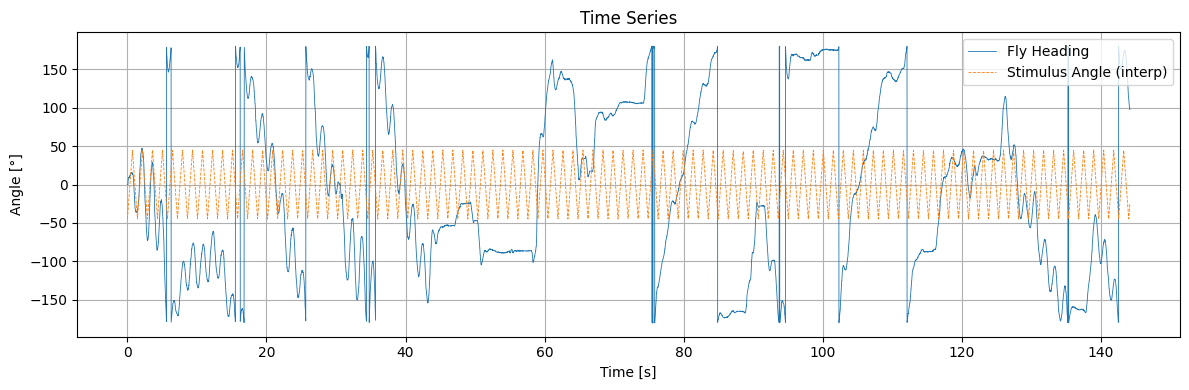

In [46]:

# Plot time series (optional)
plt.figure(figsize=(12, 4))
plt.plot(t, fly, linewidth=0.6, label='Fly Heading')
plt.plot(t, stim_i, linewidth=0.6, linestyle='--', label='Stimulus Angle (interp)')
plt.xlabel('Time [s]'); plt.ylabel('Angle [°]'); plt.title('Time Series'); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()


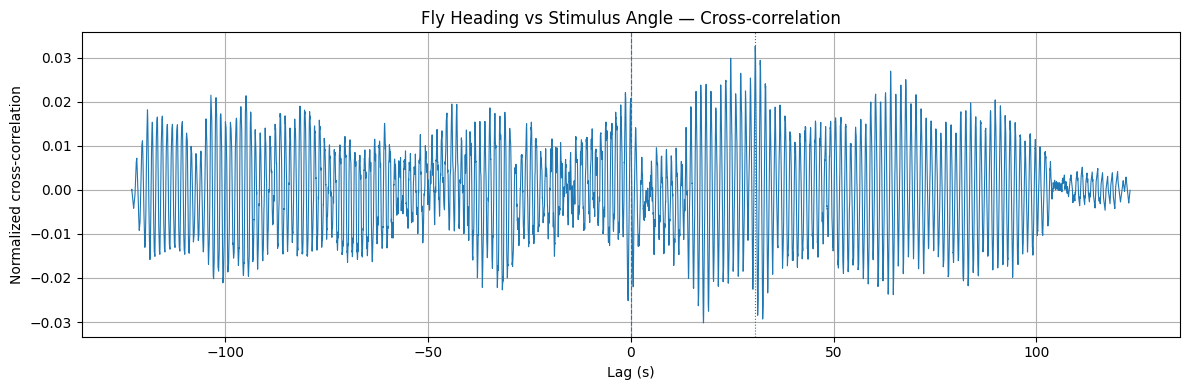

In [47]:

# Plot cross-correlation vs lag
plt.figure(figsize=(12, 4))
plt.plot(lags_sec, xc, linewidth=0.8)
plt.axvline(0, linestyle='--', linewidth=0.8)
plt.axvline(best_lag, linestyle=':', linewidth=0.8)
plt.xlabel('Lag (s)') 
plt.ylabel('Normalized cross-correlation')
plt.title('Fly Heading vs Stimulus Angle — Cross-correlation')
plt.grid(True)
plt.tight_layout()
plt.show()


### Time intervals for right and left sweep for stimulus

In [67]:
# Step 1: Convert time and angle columns to float (for computation)
stim_time = repeated_df['time [s]'].astype(float).to_numpy()
stim_angle = repeated_df['angular_shift (deg)'].astype(float).to_numpy()

# Step 2: Compute derivative to detect direction
d_angle = np.diff(stim_angle)
d_time = np.diff(stim_time)

# Prevent division by zero (in case of very small dt)
d_time[d_time == 0] = 1e-10

velocity = d_angle / d_time  # degrees per second

# Step 3: Determine direction at each time point
# We'll label "right" as +1, "left" as -1
direction_flag = np.sign(velocity)

# Step 4: Find change points in direction
# Include first index
change_points = [0]
for i in range(1, len(direction_flag)):
    if direction_flag[i] != direction_flag[i - 1]:
        change_points.append(i)

# Include last index
change_points.append(len(stim_time) - 1)

# Step 5: Build interval list
sweep_intervals = []
for i in range(len(change_points) - 1):
    start_idx = change_points[i]
    end_idx = change_points[i + 1]
    if end_idx > start_idx:
        start_time = stim_time[start_idx]
        end_time = stim_time[end_idx]
        start_angle = stim_angle[start_idx]
        end_angle = stim_angle[end_idx]

        if end_angle > start_angle:
            direction = 'right'
        elif end_angle < start_angle:
            direction = 'left'
        else:
            continue  # skip flat segments

        sweep_intervals.append({
            'start_time': start_time,
            'end_time': end_time,
            'direction': direction
        })

# Step 6: Convert to DataFrame
sweep_df = pd.DataFrame(sweep_intervals)

In [68]:
sweep_df.head()

,start_time,end_time,direction
0,0.00,0.72,right
1,0.72,1.44,left
2,1.44,2.16,right
3,2.16,2.88,left
4,2.88,3.60,right


In [69]:
fly_time = posDf['time'].astype(float).to_numpy()
fly_heading = normalized_angle.astype(float).to_numpy()

fly_turning_intervals = []

for _, row in sweep_df.iterrows():
    start = row['start_time']
    end = row['end_time']
    stim_dir = row['direction']

    # Mask for this interval
    mask = (fly_time >= start) & (fly_time <= end)
    t_interval = fly_time[mask]
    h_interval = fly_heading[mask]

    if len(h_interval) < 2:
        fly_turn = 'none'
        delta_heading = np.nan
    else:
        delta_heading = h_interval[-1] - h_interval[0]

        if delta_heading > 5:        # threshold to ignore noise
            fly_turn = 'right'
        elif delta_heading < -5:
            fly_turn = 'left'
        else:
            fly_turn = 'none'

    fly_turning_intervals.append({
        'start_time': start,
        'end_time': end,
        'stimulus_direction': stim_dir,
        'fly_turn_direction': fly_turn,
        'heading_change': delta_heading,
        'n_samples': len(h_interval)
    })

fly_turn_df = pd.DataFrame(fly_turning_intervals)
fly_turn_df.head()

,start_time,end_time,stimulus_direction,fly_turn_direction,heading_change,n_samples
0,0.00,0.72,right,right,14.725616,80
1,0.72,1.44,left,left,-47.660713,82
2,1.44,2.16,right,right,76.763222,86
3,2.16,2.88,left,left,-116.066856,76
4,2.88,3.60,right,right,101.614677,69


In [74]:
fly_turn_df['match'] = fly_turn_df['stimulus_direction'] == fly_turn_df['fly_turn_direction']
accuracy = fly_turn_df['match'].mean()  # fraction of matched turns
accuracy

0.5522388059701493

In [75]:
# Step 1: Convert stimulus time and angle to float arrays
stim_time = repeated_df['time [s]'].astype(float).to_numpy()
stim_angle = repeated_df['angular_shift (deg)'].astype(float).to_numpy()

# Step 2: Create interpolator
from scipy.interpolate import interp1d

stim_interp = interp1d(stim_time, stim_angle, bounds_error=False, fill_value="extrapolate")

# Step 3: Compute stimulus angle change for each sweep
stim_changes = []
for _, row in fly_turn_df.iterrows():
    angle_start = stim_interp(row['start_time'])
    angle_end = stim_interp(row['end_time'])
    stim_changes.append(angle_end - angle_start)

# Step 4: Add to dataframe
fly_turn_df['stimulus_angle_change'] = stim_changes
fly_turn_df.head()


,start_time,end_time,stimulus_direction,fly_turn_direction,heading_change,n_samples,match,stimulus_angle_change
0,0.00,0.72,right,right,14.725616,80,True,90.0
1,0.72,1.44,left,left,-47.660713,82,True,-90.0
2,1.44,2.16,right,right,76.763222,86,True,90.0
3,2.16,2.88,left,left,-116.066856,76,True,-90.0
4,2.88,3.60,right,right,101.614677,69,True,90.0


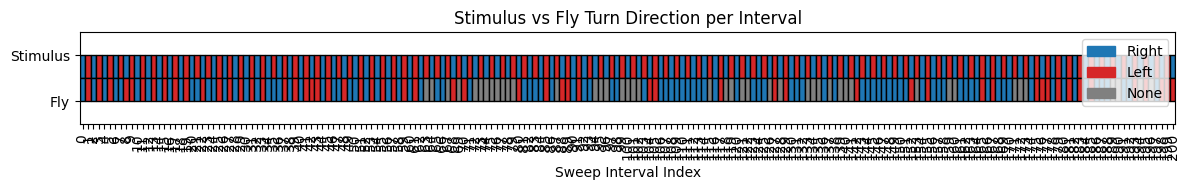

In [76]:

import matplotlib.patches as mpatches

# Map directions to color
color_map = {
    'right': 'tab:blue',
    'left': 'tab:red',
    'none': 'gray'
}

n_intervals = len(fly_turn_df)
x = np.arange(n_intervals)

# Set up plot
fig, ax = plt.subplots(figsize=(12, 2))
bar_height = 0.4

# Plot stimulus direction bars (upper row)
stim_colors = [color_map[d] for d in fly_turn_df['stimulus_direction']]
ax.bar(x, [1]*n_intervals, width=1.0, color=stim_colors, edgecolor='black', align='center', label='Stimulus')

# Plot fly direction bars (lower row)
fly_colors = [color_map[d] for d in fly_turn_df['fly_turn_direction']]
ax.bar(x, [-1]*n_intervals, width=1.0, color=fly_colors, edgecolor='black', align='center', label='Fly')

# Format axis
ax.set_yticks([1, -1])
ax.set_yticklabels(['Stimulus', 'Fly'])
ax.set_xticks(x)
ax.set_xticklabels([f"{i}" for i in x], rotation=90)
ax.set_xlabel('Sweep Interval Index')
ax.set_title('Stimulus vs Fly Turn Direction per Interval')
ax.set_xlim(-0.5, n_intervals - 0.5)
ax.set_ylim(-2, 2)
ax.grid(False)

# Add legend
patches = [
    mpatches.Patch(color='tab:blue', label='Right'),
    mpatches.Patch(color='tab:red', label='Left'),
    mpatches.Patch(color='gray', label='None')
]
ax.legend(handles=patches, loc='upper right')

plt.tight_layout()
plt.show()


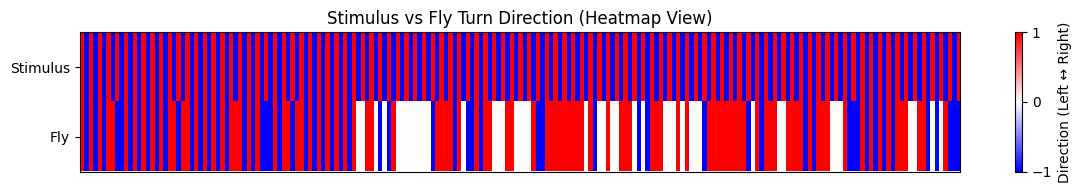

In [83]:

# Encode directions as integers
dir_to_int = {'left': -1, 'none': 0, 'right': 1}
stim_dir_encoded = [dir_to_int[d] for d in fly_turn_df['stimulus_direction']]
fly_dir_encoded = [dir_to_int[d] for d in fly_turn_df['fly_turn_direction']]

# Stack into 2D array
data = np.vstack([stim_dir_encoded, fly_dir_encoded])

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 2))
im = ax.imshow(data, aspect='auto', cmap='bwr', vmin=-1, vmax=1)

ax.set_yticks([0, 1])
ax.set_yticklabels(['Stimulus', 'Fly'])
ax.set_xticks([])
ax.set_title('Stimulus vs Fly Turn Direction (Heatmap View)')

plt.colorbar(im, ax=ax, label='Direction (Left ↔ Right)', ticks=[-1, 0, 1])
plt.tight_layout()
plt.show()


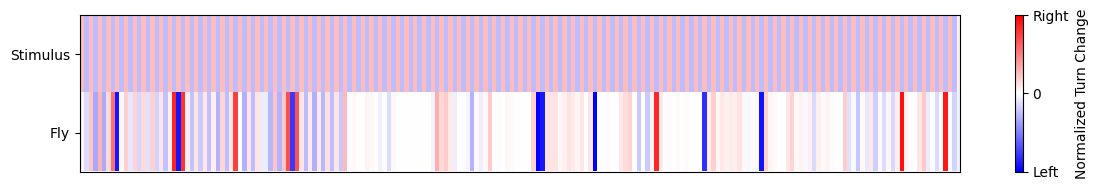

In [89]:


# Extract from DataFrame
stim_angle_change = fly_turn_df['stimulus_angle_change'].to_numpy()
heading_change = fly_turn_df['heading_change'].to_numpy()

# Determine shared max magnitude across both rows
shared_max = max(np.abs(stim_angle_change).max(), np.abs(heading_change).max())

# Normalize to [-1, 1]
stim_normalized = stim_angle_change / shared_max
fly_normalized = heading_change / shared_max

# Stack into heatmap
heatmap_data = np.vstack([stim_normalized, fly_normalized])

# Plot
fig, ax = plt.subplots(figsize=(12, 2))
im = ax.imshow(heatmap_data, aspect='auto', cmap='bwr', vmin=-1, vmax=1)

# Axis settings
ax.set_yticks([0, 1])
ax.set_yticklabels(['Stimulus', 'Fly'])
ax.set_xticks([])
# ax.set_title('Turn Direction & Strength (Normalized to Shared Max)')

# Colorbar
cbar = plt.colorbar(im, ax=ax, label='Normalized Turn Change')
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['Left', '0', 'Right'])

plt.tight_layout()
plt.show()



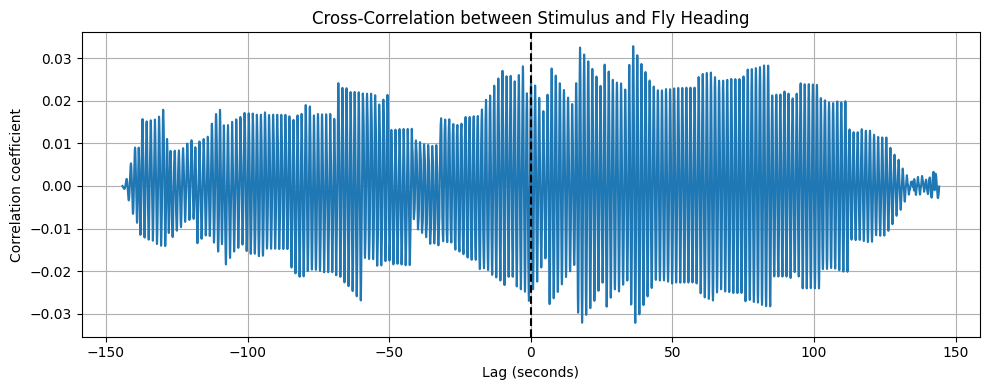

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import correlate

# Step 1: Extract time and angle data
stim_time = repeated_df['time [s]'].astype(float).to_numpy()
stim_angle = repeated_df['angular_shift (deg)'].astype(float).to_numpy()

fly_time = posDf['time'].astype(float).to_numpy()
fly_heading = normalized_angle.astype(float).to_numpy()

# Step 2: Define common time base
dt = 0.01  # 100 Hz sampling
common_time = np.arange(
    max(fly_time.min(), stim_time.min()),
    min(fly_time.max(), stim_time.max()),
    dt
)

# Step 3: Interpolate both signals
stim_interp = interp1d(stim_time, stim_angle, bounds_error=False, fill_value="extrapolate")
fly_interp = interp1d(fly_time, fly_heading, bounds_error=False, fill_value="extrapolate")

stim_uniform = stim_interp(common_time)
fly_uniform = fly_interp(common_time)

# Step 4: Z-score both signals (mean=0, std=1)
stim_z = (stim_uniform - np.nanmean(stim_uniform)) / np.nanstd(stim_uniform)
fly_z = (fly_uniform - np.nanmean(fly_uniform)) / np.nanstd(fly_uniform)

# Step 5: Compute cross-correlation
corr = correlate(fly_z, stim_z, mode='full')
lags = np.arange(-len(fly_z) + 1, len(fly_z)) * dt

# Normalize correlation
corr = corr / len(fly_z)

# Step 6: Plot
plt.figure(figsize=(10, 4))
plt.plot(lags, corr)
plt.axvline(0, color='k', linestyle='--')
plt.title('Cross-Correlation between Stimulus and Fly Heading')
plt.xlabel('Lag (seconds)')
plt.ylabel('Correlation coefficient')
plt.grid(True)
plt.tight_layout()
plt.show()


In [91]:
fly_velocity = np.gradient(fly_uniform, dt)


In [92]:
from scipy.signal import butter, filtfilt

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

fs = 1 / dt  # Sampling rate (Hz)
stim_filtered = bandpass_filter(stim_z, 0.2, 2.0, fs)
fly_filtered = bandpass_filter(fly_velocity, 0.2, 2.0, fs)


In [93]:
max_lag_seconds = 10
max_lag_samples = int(max_lag_seconds / dt)

corr = correlate(fly_filtered, stim_filtered, mode='full') / len(fly_filtered)
lags = np.arange(-len(fly_filtered) + 1, len(fly_filtered)) * dt
center = len(corr) // 2
corr = corr[center - max_lag_samples : center + max_lag_samples]
lags = lags[center - max_lag_samples : center + max_lag_samples]


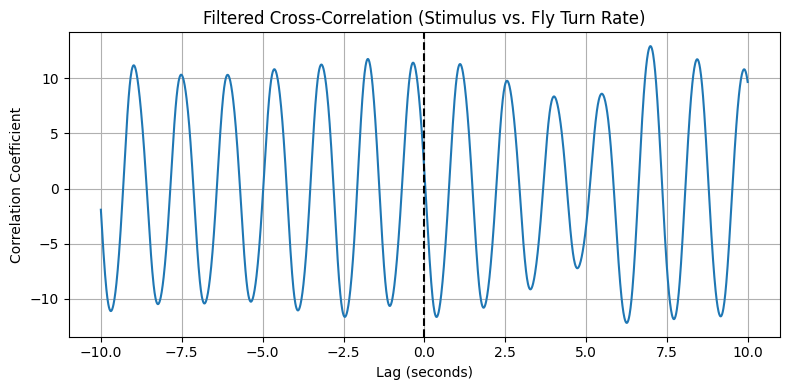

In [94]:
plt.figure(figsize=(8, 4))
plt.plot(lags, corr)
plt.axvline(0, color='k', linestyle='--')
plt.title('Filtered Cross-Correlation (Stimulus vs. Fly Turn Rate)')
plt.xlabel('Lag (seconds)')
plt.ylabel('Correlation Coefficient')
plt.grid(True)
plt.tight_layout()
plt.show()


In [95]:
fly_turn_df['stimulus_direction']  # 'left' or 'right'
fly_turn_df['heading_change']      # degrees change


0       14.725616
1      -47.660713
2       76.763222
3     -116.066856
4      101.614677
          ...    
196     -0.617706
197    307.257324
198     -5.536484
199    -58.252899
200    -13.793671
Name: heading_change, Length: 201, dtype: float64

In [96]:
def classify_behavior(row, threshold=5):
    delta = row['heading_change']
    stim_dir = row['stimulus_direction']
    
    if abs(delta) < threshold:
        return 'neutral'
    elif (stim_dir == 'right' and delta > threshold) or (stim_dir == 'left' and delta < -threshold):
        return 'tracking'
    else:
        return 'anti-tracking'

fly_turn_df['tracking_category'] = fly_turn_df.apply(classify_behavior, axis=1)


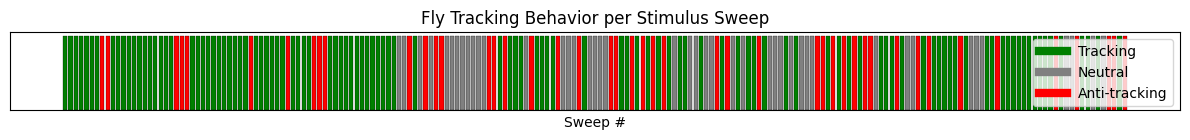

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assign colors to categories
color_map = {'tracking': 'green', 'neutral': 'gray', 'anti-tracking': 'red'}
colors = fly_turn_df['tracking_category'].map(color_map)

# Plot behavior over time
plt.figure(figsize=(12, 1.5))
plt.bar(range(len(fly_turn_df)), [1]*len(fly_turn_df), color=colors, edgecolor='k', linewidth=0.2)
plt.xticks([])
plt.yticks([])
plt.title("Fly Tracking Behavior per Stimulus Sweep")
plt.xlabel("Sweep #")
plt.legend(handles=[
    plt.Line2D([0], [0], color='green', lw=6, label='Tracking'),
    plt.Line2D([0], [0], color='gray', lw=6, label='Neutral'),
    plt.Line2D([0], [0], color='red', lw=6, label='Anti-tracking')
])
plt.tight_layout()
plt.show()


In [98]:
fly_turn_df['tracking_category'].value_counts(normalize=True)


tracking         0.552239
anti-tracking    0.228856
neutral          0.218905
Name: tracking_category, dtype: float64

In [99]:
from scipy.signal import correlate
from scipy.interpolate import interp1d

def get_crosscorr_segments(df, category, stim_time, stim_angle, fly_time, fly_heading, dt=0.01):
    # Interpolators
    stim_interp = interp1d(stim_time, stim_angle, bounds_error=False, fill_value="extrapolate")
    fly_interp = interp1d(fly_time, fly_heading, bounds_error=False, fill_value="extrapolate")

    aligned_stim = []
    aligned_fly = []

    for _, row in df[df['tracking_category'] == category].iterrows():
        t0, t1 = row['start_time'], row['end_time']
        t_segment = np.arange(t0, t1, dt)
        
        if len(t_segment) < 2:
            continue

        stim_seg = stim_interp(t_segment)
        fly_seg = fly_interp(t_segment)
        fly_vel = np.gradient(fly_seg, dt)

        # Z-score
        stim_seg = (stim_seg - np.mean(stim_seg)) / np.std(stim_seg)
        fly_vel = (fly_vel - np.mean(fly_vel)) / np.std(fly_vel)

        aligned_stim.append(stim_seg)
        aligned_fly.append(fly_vel)

    # Pad to same length (min length across all segments)
    min_len = min(map(len, aligned_stim))
    aligned_stim = np.array([s[:min_len] for s in aligned_stim])
    aligned_fly = np.array([f[:min_len] for f in aligned_fly])

    # Average across sweeps
    stim_avg = np.mean(aligned_stim, axis=0)
    fly_avg = np.mean(aligned_fly, axis=0)

    # Cross-correlation
    corr = correlate(fly_avg, stim_avg, mode='full')
    lags = np.arange(-len(stim_avg) + 1, len(stim_avg)) * dt
    corr /= len(stim_avg)  # Normalize

    return lags, corr


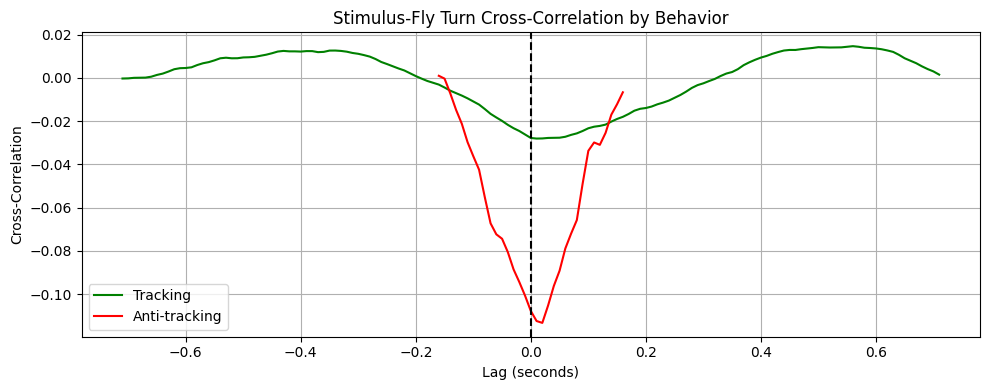

In [100]:
# Compute
lags_track, corr_track = get_crosscorr_segments(fly_turn_df, 'tracking', stim_time, stim_angle, fly_time, fly_heading)
lags_anti, corr_anti = get_crosscorr_segments(fly_turn_df, 'anti-tracking', stim_time, stim_angle, fly_time, fly_heading)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(lags_track, corr_track, label='Tracking', color='green')
plt.plot(lags_anti, corr_anti, label='Anti-tracking', color='red')
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Lag (seconds)')
plt.ylabel('Cross-Correlation')
plt.title('Stimulus-Fly Turn Cross-Correlation by Behavior')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
